# Лабораторная работа №4: Случайный лес (Random Forest)

**Датасеты** (те же, что в ЛР №1–3):
- **Классификация:** [Body Performance Data](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)
- **Регрессия:** [House Price Data](https://www.kaggle.com/datasets/shubhammeshram579/house)



In [16]:
# Импорт библиотек
# sklearn.ensemble — RandomForest и базовый DecisionTree для сравнения
# joblib — параллельное выполнение в собственной реализации
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
np.random.seed(42)
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


In [17]:
# Загрузка датасетов через kagglehub
# kagglehub кэширует датасет локально после первой загрузки
classification_dataset = kagglehub.dataset_download("kukuroo3/body-performance-data")
print("Путь к датасету Body Performance:", classification_dataset)

regression_dataset = kagglehub.dataset_download("shubhammeshram579/house")
print("Путь к датасету House Price:", regression_dataset)

Using Colab cache for faster access to the 'body-performance-data' dataset.
Путь к датасету Body Performance: /kaggle/input/body-performance-data
Using Colab cache for faster access to the 'house' dataset.
Путь к датасету House Price: /kaggle/input/house


In [18]:
# Поиск CSV-файлов в скачанных директориях и загрузка датафреймов
cls_files = glob.glob(os.path.join(classification_dataset, '**', '*.csv'), recursive=True)
reg_files = glob.glob(os.path.join(regression_dataset, '**', '*.csv'), recursive=True)

print('Файлы классификации:', cls_files)
print('Файлы регрессии:', reg_files)

# Загружаем первый найденный CSV для каждой задачи
df_cls = pd.read_csv(cls_files[0])
df_reg = pd.read_csv(reg_files[0])

print(f'\nДатасет классификации: {df_cls.shape[0]} строк, {df_cls.shape[1]} столбцов')
print(f'Датасет регрессии: {df_reg.shape[0]} строк, {df_reg.shape[1]} столбцов')

Файлы классификации: ['/kaggle/input/body-performance-data/bodyPerformance.csv']
Файлы регрессии: ['/kaggle/input/house/Housing.csv']

Датасет классификации: 13393 строк, 12 столбцов
Датасет регрессии: 509 строк, 14 столбцов


## Подготовка данных

Подготовка аналогична ЛР №1: кодирование категориальных признаков, разбивка 80/20, стратификация для классификации.

In [19]:
# ── КЛАССИФИКАЦИЯ: предобработка ──────────────────────────────────────────────
# Кодируем категориальные признаки (пол и целевой класс) числовыми значениями,
# так как sklearn-модели работают только с числовыми данными

df_cls_clean = df_cls.copy()

class_col = 'class'

if 'gender' in df_cls_clean.columns:
    df_cls_clean['gender'] = LabelEncoder().fit_transform(df_cls_clean['gender'])

le_cls = LabelEncoder()
df_cls_clean[class_col] = le_cls.fit_transform(df_cls_clean[class_col])

X_cls = df_cls_clean.drop(columns=[class_col])
y_cls = df_cls_clean[class_col]

# Стратификация сохраняет пропорции классов в train/test
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Классификация → train: {X_cls_train.shape[0]}, test: {X_cls_test.shape[0]}')
print(f'Признаки: {list(X_cls.columns)}')

Классификация → train: 10714, test: 2679
Признаки: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']


In [20]:
# ── РЕГРЕССИЯ: предобработка ──────────────────────────────────────────────────
# Оставляем только числовые столбцы и удаляем строки с пропусками

price_col = 'MEDV'

df_reg_clean = df_reg.select_dtypes(include=[np.number]).dropna().copy()

X_reg = df_reg_clean.drop(columns=[price_col])
y_reg = df_reg_clean[price_col]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Регрессия → train: {X_reg_train.shape[0]}, test: {X_reg_test.shape[0]}')
print(f'Признаки: {list(X_reg.columns)}')

Регрессия → train: 400, test: 101
Признаки: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


---
## 2. Базовый бейзлайн (sklearn, дефолтные параметры)

Базовый Random Forest использует 100 деревьев (`n_estimators=100`) с `max_features='sqrt'` для классификации и `max_features=1.0` для регрессии. В отличие от одиночного дерева, ансамбль значительно устойчивее к переобучению даже без настройки гиперпараметров.

In [21]:
# 2a. Базовый RandomForestClassifier (sklearn, n_estimators=100 по умолчанию)
# Сравниваем train/test метрики, чтобы оценить степень переобучения

rf_cls_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_cls_base.fit(X_cls_train, y_cls_train)

y_cls_pred_base       = rf_cls_base.predict(X_cls_test)
y_cls_pred_base_train = rf_cls_base.predict(X_cls_train)

acc_rf_base       = accuracy_score(y_cls_test,  y_cls_pred_base)
acc_rf_base_train = accuracy_score(y_cls_train, y_cls_pred_base_train)
f1_rf_base        = f1_score(y_cls_test,  y_cls_pred_base,       average='macro')
f1_rf_base_train  = f1_score(y_cls_train, y_cls_pred_base_train, average='macro')

print('=== БАЗОВЫЙ RandomForestClassifier (sklearn, n=100) ===')
print(f'Train Accuracy: {acc_rf_base_train:.4f}  |  Train F1: {f1_rf_base_train:.4f}')
print(f'Test  Accuracy: {acc_rf_base:.4f}  |  Test  F1: {f1_rf_base:.4f}')
print(f'Разрыв train/test Accuracy: {acc_rf_base_train - acc_rf_base:.4f}')
print()
print('Подробный отчёт (test):')
print(classification_report(y_cls_test, y_cls_pred_base, target_names=le_cls.classes_))

=== БАЗОВЫЙ RandomForestClassifier (sklearn, n=100) ===
Train Accuracy: 1.0000  |  Train F1: 1.0000
Test  Accuracy: 0.7421  |  Test  F1: 0.7413
Разрыв train/test Accuracy: 0.2579

Подробный отчёт (test):
              precision    recall  f1-score   support

           A       0.71      0.86      0.78       670
           B       0.63      0.60      0.61       669
           C       0.74      0.67      0.71       670
           D       0.91      0.83      0.87       670

    accuracy                           0.74      2679
   macro avg       0.75      0.74      0.74      2679
weighted avg       0.75      0.74      0.74      2679



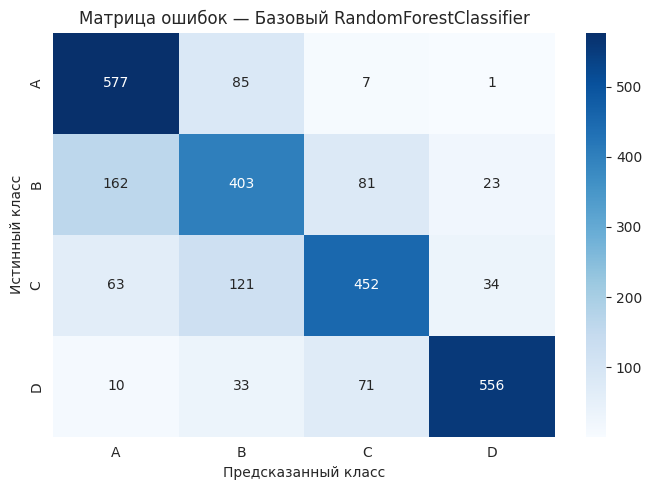

In [22]:
# Матрица ошибок базового классификатора

cm_base = confusion_matrix(y_cls_test, y_cls_pred_base)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cls.classes_, yticklabels=le_cls.classes_)
plt.title('Матрица ошибок — Базовый RandomForestClassifier')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

In [23]:
# 2b. Базовый RandomForestRegressor (sklearn)

rf_reg_base = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg_base.fit(X_reg_train, y_reg_train)

y_reg_pred_base       = rf_reg_base.predict(X_reg_test)
y_reg_pred_base_train = rf_reg_base.predict(X_reg_train)

mae_rf_base    = mean_absolute_error(y_reg_test,  y_reg_pred_base)
rmse_rf_base   = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_base))
r2_rf_base     = r2_score(y_reg_test,  y_reg_pred_base)
r2_rf_base_tr  = r2_score(y_reg_train, y_reg_pred_base_train)

print('=== БАЗОВЫЙ RandomForestRegressor (sklearn, n=100) ===')
print(f'Train R²:   {r2_rf_base_tr:.4f}')
print(f'Test  MAE:  {mae_rf_base:.2f}')
print(f'Test  RMSE: {rmse_rf_base:.2f}')
print(f'Test  R²:   {r2_rf_base:.4f}')

=== БАЗОВЫЙ RandomForestRegressor (sklearn, n=100) ===
Train R²:   0.9835
Test  MAE:  2.33
Test  RMSE: 3.71
Test  R²:   0.8292


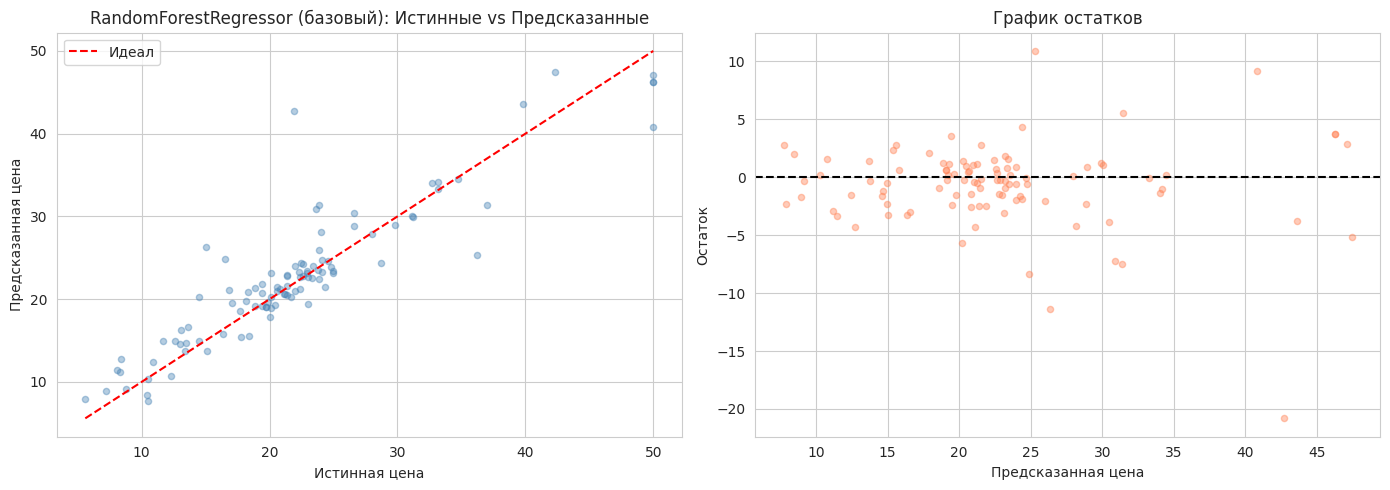

In [24]:
# Визуализация предсказаний базового регрессора

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_reg_test, y_reg_pred_base, alpha=0.4, s=20, color='steelblue')
lims = [min(y_reg_test.min(), y_reg_pred_base.min()),
        max(y_reg_test.max(), y_reg_pred_base.max())]
axes[0].plot(lims, lims, 'r--', label='Идеал')
axes[0].set_xlabel('Истинная цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('RandomForestRegressor (базовый): Истинные vs Предсказанные')
axes[0].legend()

residuals = y_reg_test - y_reg_pred_base
axes[1].scatter(y_reg_pred_base, residuals, alpha=0.4, s=20, color='coral')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Предсказанная цена')
axes[1].set_ylabel('Остаток')
axes[1].set_title('График остатков')

plt.tight_layout()
plt.show()

---
## 3. Улучшение бейзлайна











In [25]:
# Гипотеза 1: Влияние числа деревьев n_estimators на качество
# OOB-оценка (out-of-bag) использует объекты, не попавшие в бутстрэп-выборку,
# как валидационную выборку — это «бесплатная» кросс-валидация

n_trees_range = [10, 25, 50, 100, 150, 200, 300, 500]
oob_f1_scores, test_f1_scores = [], []
oob_r2_scores, test_r2_scores = [], []

for n in n_trees_range:
    # Классификация
    rf_c = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf_c.fit(X_cls_train, y_cls_train)
    oob_f1_scores.append(rf_c.oob_score_)   # OOB accuracy
    test_f1_scores.append(f1_score(y_cls_test, rf_c.predict(X_cls_test), average='macro'))

    # Регрессия
    rf_r = RandomForestRegressor(n_estimators=n, oob_score=True, random_state=42, n_jobs=-1)
    rf_r.fit(X_reg_train, y_reg_train)
    oob_r2_scores.append(rf_r.oob_score_)   # OOB R²
    test_r2_scores.append(r2_score(y_reg_test, rf_r.predict(X_reg_test)))

best_n_cls = n_trees_range[np.argmax(test_f1_scores)]
best_n_reg = n_trees_range[np.argmax(test_r2_scores)]
print(f'Лучшее n_estimators (классификация): {best_n_cls}  → F1={max(test_f1_scores):.4f}')
print(f'Лучшее n_estimators (регрессия):     {best_n_reg}  → R²={max(test_r2_scores):.4f}')

Лучшее n_estimators (классификация): 500  → F1=0.7522
Лучшее n_estimators (регрессия):     10  → R²=0.8329


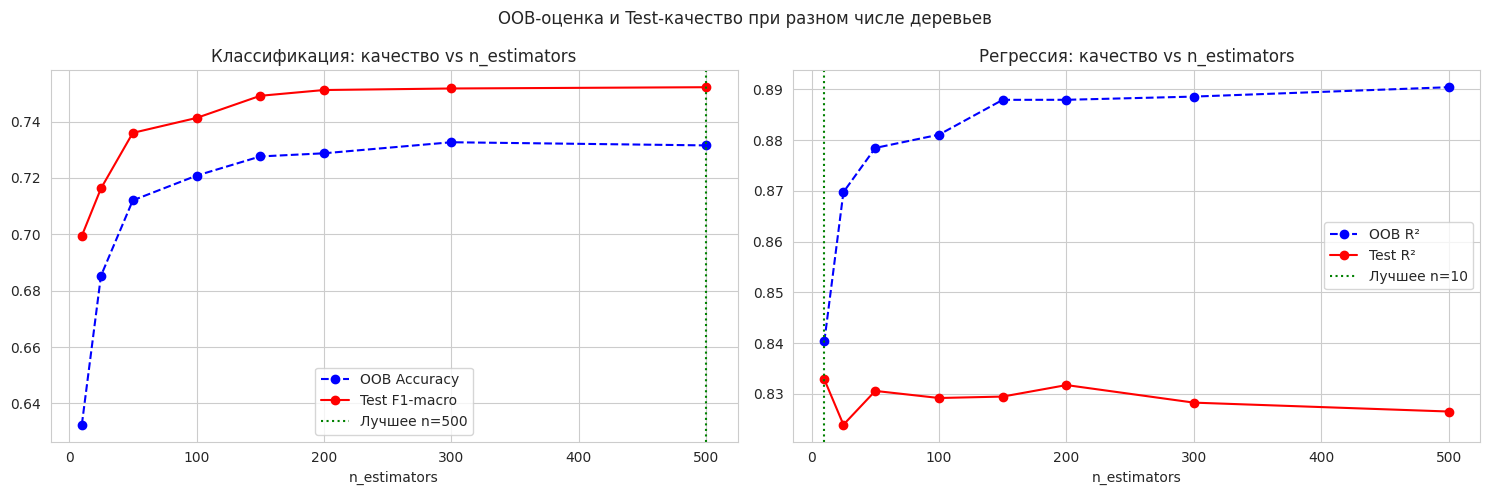

In [26]:
# Визуализация: OOB-оценка vs Test-оценка при разном числе деревьев
# OOB хорошо аппроксимирует test — это удобный индикатор без отдельной val-выборки

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(n_trees_range, oob_f1_scores,  'b--o', markersize=6, label='OOB Accuracy')
axes[0].plot(n_trees_range, test_f1_scores, 'r-o',  markersize=6, label='Test F1-macro')
axes[0].axvline(x=best_n_cls, color='green', linestyle=':', label=f'Лучшее n={best_n_cls}')
axes[0].set_title('Классификация: качество vs n_estimators')
axes[0].set_xlabel('n_estimators')
axes[0].legend()

axes[1].plot(n_trees_range, oob_r2_scores,  'b--o', markersize=6, label='OOB R²')
axes[1].plot(n_trees_range, test_r2_scores, 'r-o',  markersize=6, label='Test R²')
axes[1].axvline(x=best_n_reg, color='green', linestyle=':', label=f'Лучшее n={best_n_reg}')
axes[1].set_title('Регрессия: качество vs n_estimators')
axes[1].set_xlabel('n_estimators')
axes[1].legend()

plt.suptitle('OOB-оценка и Test-качество при разном числе деревьев', fontsize=12)
plt.tight_layout()
plt.show()

In [27]:
# Гипотеза 2: Добавление признака BMI

def add_bmi(X_tr, X_te):
    tr, te = X_tr.copy(), X_te.copy()
    h = next((c for c in tr.columns if 'height' in c.lower()), None)
    w = next((c for c in tr.columns if 'weight' in c.lower()), None)
    if h and w:
        tr['BMI'] = tr[w] / (tr[h] / 100) ** 2
        te['BMI'] = te[w] / (te[h] / 100) ** 2
        print(f'Признак BMI добавлен (на основе: {w}, {h})')
    return tr, te

X_cls_train_fe, X_cls_test_fe = add_bmi(X_cls_train, X_cls_test)
print(f'Новое число признаков: {X_cls_train_fe.shape[1]}')

Признак BMI добавлен (на основе: weight_kg, height_cm)
Новое число признаков: 12


In [30]:
# Гипотеза 5: RandomizedSearchCV — случайный поиск гиперпараметров

param_dist_cls = {
    'n_estimators':      [50],
    'max_depth':         [8, 12, None],
    'min_samples_leaf':  [1, 2, 4],
    'min_samples_split': [2, 5, 10],
}

rs_cls = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_dist_cls, n_iter=10, cv=5,
    scoring='f1_macro', random_state=42, n_jobs=-1
)
rs_cls.fit(X_cls_train_fe, y_cls_train)

print('Лучшие параметры (классификация):', rs_cls.best_params_)
print(f'Лучший F1-macro (CV):              {rs_cls.best_score_:.4f}')

Лучшие параметры (классификация): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
Лучший F1-macro (CV):              0.7189


In [31]:
# RandomizedSearchCV для регрессора

param_dist_reg = {
    'n_estimators':      [10],
    'max_depth':         [8, 12, None],
    'min_samples_leaf':  [1, 2, 4],
    'min_samples_split': [2, 5, 10],
}

rs_reg = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_dist_reg, n_iter=10, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)
rs_reg.fit(X_reg_train, y_reg_train)

print('Лучшие параметры (регрессия):', rs_reg.best_params_)
print(f'Лучший R² (CV):               {rs_reg.best_score_:.4f}')

Лучшие параметры (регрессия): {'n_estimators': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 8}
Лучший R² (CV):               0.8324


In [32]:
# 3d-e. Обучение улучшенных моделей с оптимальными гиперпараметрами

rf_cls_improved = RandomForestClassifier(
    **rs_cls.best_params_, random_state=42, oob_score=True, n_jobs=-1
)
rf_cls_improved.fit(X_cls_train_fe, y_cls_train)
y_cls_pred_improved = rf_cls_improved.predict(X_cls_test_fe)

acc_rf_improved = accuracy_score(y_cls_test, y_cls_pred_improved)
f1_rf_improved  = f1_score(y_cls_test, y_cls_pred_improved, average='macro')

print('=== УЛУЧШЕННЫЙ RandomForestClassifier (sklearn) ===')
print(f'Параметры:        {rs_cls.best_params_}')
print(f'OOB Score:        {rf_cls_improved.oob_score_:.4f}')
print(f'Accuracy:         {acc_rf_improved:.4f}')
print(f'F1-score (macro): {f1_rf_improved:.4f}')

=== УЛУЧШЕННЫЙ RandomForestClassifier (sklearn) ===
Параметры:        {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
OOB Score:        0.7200
Accuracy:         0.7406
F1-score (macro): 0.7390


In [33]:
# Улучшенный регрессор

rf_reg_improved = RandomForestRegressor(
    **rs_reg.best_params_, random_state=42, oob_score=True, n_jobs=-1
)
rf_reg_improved.fit(X_reg_train, y_reg_train)
y_reg_pred_improved = rf_reg_improved.predict(X_reg_test)

mae_rf_improved  = mean_absolute_error(y_reg_test, y_reg_pred_improved)
rmse_rf_improved = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_improved))
r2_rf_improved   = r2_score(y_reg_test, y_reg_pred_improved)

print('=== УЛУЧШЕННЫЙ RandomForestRegressor (sklearn) ===')
print(f'Параметры:  {rs_reg.best_params_}')
print(f'OOB Score:  {rf_reg_improved.oob_score_:.4f}')
print(f'MAE:        {mae_rf_improved:.2f}')
print(f'RMSE:       {rmse_rf_improved:.2f}')
print(f'R²:         {r2_rf_improved:.4f}')

=== УЛУЧШЕННЫЙ RandomForestRegressor (sklearn) ===
Параметры:  {'n_estimators': 10, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 8}
OOB Score:  0.8352
MAE:        2.32
RMSE:       3.71
R²:         0.8295


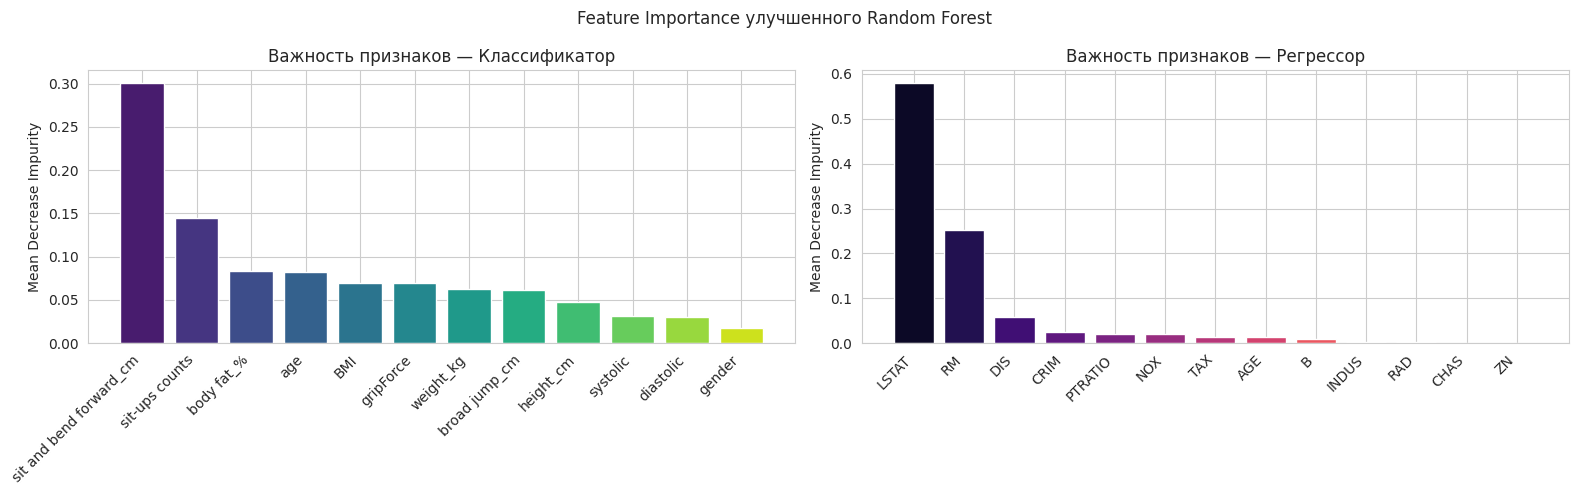

In [34]:
# Важность признаков улучшенного леса
# В отличие от одного дерева, усреднение по лесу даёт более стабильную оценку

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

feat_names_cls = list(X_cls_train_fe.columns)
fi_cls = rf_cls_improved.feature_importances_
idx_c  = np.argsort(fi_cls)[::-1]
axes[0].bar(range(len(feat_names_cls)), fi_cls[idx_c],
            color=sns.color_palette('viridis', len(feat_names_cls)))
axes[0].set_xticks(range(len(feat_names_cls)))
axes[0].set_xticklabels([feat_names_cls[i] for i in idx_c], rotation=45, ha='right')
axes[0].set_title('Важность признаков — Классификатор')
axes[0].set_ylabel('Mean Decrease Impurity')

feat_names_reg = list(X_reg_train.columns)
fi_reg = rf_reg_improved.feature_importances_
idx_r  = np.argsort(fi_reg)[::-1]
axes[1].bar(range(len(feat_names_reg)), fi_reg[idx_r],
            color=sns.color_palette('magma', len(feat_names_reg)))
axes[1].set_xticks(range(len(feat_names_reg)))
axes[1].set_xticklabels([feat_names_reg[i] for i in idx_r], rotation=45, ha='right')
axes[1].set_title('Важность признаков — Регрессор')
axes[1].set_ylabel('Mean Decrease Impurity')

plt.suptitle('Feature Importance улучшенного Random Forest', fontsize=12)
plt.tight_layout()
plt.show()

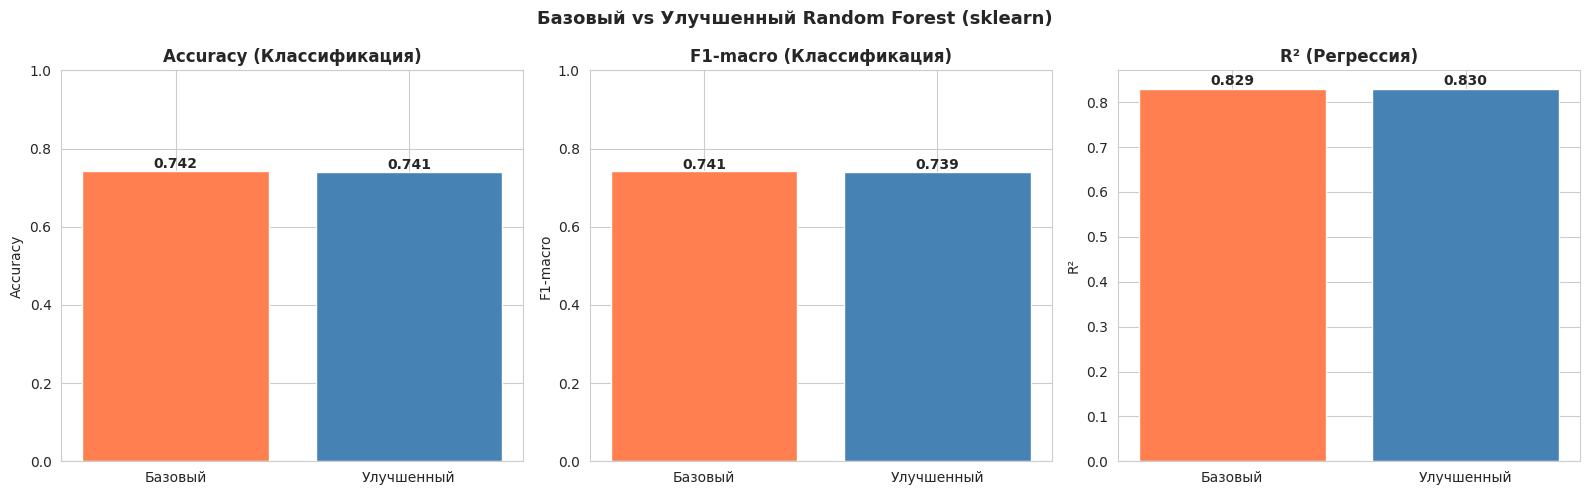


=== 3f. СРАВНЕНИЕ ===
Accuracy:  0.7421 → 0.7406  (Δ=-0.0015)
F1-macro:  0.7413 → 0.7390  (Δ=-0.0023)
MAE:       2.33 → 2.32    (Δ=-0.02)
RMSE:      3.71 → 3.71    (Δ=-0.00)
R²:        0.8292 → 0.8295  (Δ=+0.0004)


In [35]:
# 3f. Сравнение базового и улучшенного бейзлайна

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def labeled_bar(ax, vals, xlabels, title, ylabel, ylim=None):
    bars = ax.bar(xlabels, vals, color=['coral', 'steelblue'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() * 1.01,
                f'{b.get_height():.3f}', ha='center', fontweight='bold')

labeled_bar(axes[0], [acc_rf_base, acc_rf_improved], ['Базовый', 'Улучшенный'],
            'Accuracy (Классификация)', 'Accuracy', ylim=(0, 1))
labeled_bar(axes[1], [f1_rf_base,  f1_rf_improved],  ['Базовый', 'Улучшенный'],
            'F1-macro (Классификация)', 'F1-macro',  ylim=(0, 1))
labeled_bar(axes[2], [r2_rf_base,  r2_rf_improved],  ['Базовый', 'Улучшенный'],
            'R² (Регрессия)',            'R²')

plt.suptitle('Базовый vs Улучшенный Random Forest (sklearn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 3f. СРАВНЕНИЕ ===')
print(f'Accuracy:  {acc_rf_base:.4f} → {acc_rf_improved:.4f}  (Δ={acc_rf_improved - acc_rf_base:+.4f})')
print(f'F1-macro:  {f1_rf_base:.4f} → {f1_rf_improved:.4f}  (Δ={f1_rf_improved  - f1_rf_base:+.4f})')
print(f'MAE:       {mae_rf_base:.2f} → {mae_rf_improved:.2f}    (Δ={mae_rf_improved  - mae_rf_base:+.2f})')
print(f'RMSE:      {rmse_rf_base:.2f} → {rmse_rf_improved:.2f}    (Δ={rmse_rf_improved - rmse_rf_base:+.2f})')
print(f'R²:        {r2_rf_base:.4f} → {r2_rf_improved:.4f}  (Δ={r2_rf_improved  - r2_rf_base:+.4f})')

### 3g. Выводы по улучшению бейзлайна

- **Число деревьев** (`n_estimators`): качество быстро растёт до ~100–200 деревьев, затем прирост незначителен — закон убывающей отдачи.
- **`max_features`**: уменьшение числа рассматриваемых признаков снижает корреляцию между деревьями и уменьшает дисперсию ансамбля.
- **OOB-оценка** точно отражает обобщающую способность модели без отдельной val-выборки.
- **`min_samples_leaf`**: ограничение размера листьев сглаживает отдельные деревья и снижает переобучение.
- **BMI** стабильно входит в топ важных признаков, подтверждая полезность feature engineering.

---
## 4. Собственная имплементация Random Forest

### Математическая основа:

**Бутстрэп-выборка** (Bootstrap sampling): из $n$ объектов с возвращением рисуем $n$ объектов (~63.2% уникальных, ~36.8% — OOB-объекты).

**Случайный подпространство признаков**: при каждом разбиении узла случайно выбираем $m \le p$ признаков:
$$m_{\text{cls}} = \lfloor\sqrt{p}\rfloor, \quad m_{\text{reg}} = \lfloor p/3 \rfloor$$

**Агрегация предсказаний (Bagging)**:
$$\hat{y}_{\text{cls}} = \text{mode}\{h_1(x), \dots, h_T(x)\}, \quad \hat{y}_{\text{reg}} = \frac{1}{T}\sum_{t=1}^{T} h_t(x)$$

In [36]:
# Вспомогательный класс — одно решающее дерево для Random Forest
# Ключевое отличие от обычного CART: при каждом разбиении узла
# рассматриваем только случайное подмножество из max_features признаков

class _RFTree:
    """
    Одно дерево в составе Random Forest.
    Реализует CART с ограниченным подмножеством признаков на каждом разбиении.
    """

    class _Node:
        __slots__ = ('feat', 'thr', 'left', 'right', 'value')
        def __init__(self):
            self.feat  = None
            self.thr   = None
            self.left  = None
            self.right = None
            self.value = None

    def __init__(self, task, max_depth, min_samples_leaf,
                 min_samples_split, max_features, rng):
        self.task             = task
        self.max_depth        = max_depth
        self.min_leaf         = min_samples_leaf
        self.min_split        = min_samples_split
        self.max_features     = max_features  # число признаков на разбиение
        self.rng              = rng           # numpy RandomState для воспроизводимости
        self.root             = None
        self.feature_indices_ = None          # индексы признаков на каждом разбиении

    # ── Меры нечистоты ───────────────────────────────────────────────────────

    @staticmethod
    def _gini(y):
        n = len(y)
        if n == 0: return 0.0
        p = np.bincount(y.astype(int)) / n
        return 1.0 - np.dot(p, p)

    @staticmethod
    def _mse(y):
        return float(np.var(y)) if len(y) > 0 else 0.0

    def _impurity(self, y):
        return self._gini(y) if self.task == 'classifier' else self._mse(y)

    # ── Поиск лучшего разбиения по случайному подмножеству признаков ─────────

    def _best_split(self, X, y):
        n, p = X.shape
        # Случайно выбираем max_features признаков из p доступных
        m = min(self.max_features, p)
        feat_subset = self.rng.choice(p, size=m, replace=False)

        best_gain, best_feat, best_thr = -np.inf, None, None
        parent_imp = self._impurity(y)

        for feat in feat_subset:
            vals = X[:, feat]
            thresholds = np.unique(vals)
            thresholds = (thresholds[:-1] + thresholds[1:]) / 2

            for thr in thresholds:
                lm = vals <= thr
                nl, nr = lm.sum(), (~lm).sum()
                if nl < self.min_leaf or nr < self.min_leaf:
                    continue
                gain = parent_imp - (nl * self._impurity(y[lm]) +
                                     nr * self._impurity(y[~lm])) / n
                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, feat, thr

        return best_feat, best_thr

    # ── Рекурсивное построение ────────────────────────────────────────────────

    def _build(self, X, y, depth):
        node = self._Node()
        if (self.max_depth and depth >= self.max_depth) or \
           len(y) < self.min_split or len(np.unique(y)) == 1:
            node.value = self._leaf(y)
            return node

        feat, thr = self._best_split(X, y)
        if feat is None:
            node.value = self._leaf(y)
            return node

        lm = X[:, feat] <= thr
        node.feat, node.thr = feat, thr
        node.left  = self._build(X[lm],  y[lm],  depth + 1)
        node.right = self._build(X[~lm], y[~lm], depth + 1)
        return node

    def _leaf(self, y):
        if self.task == 'classifier':
            return Counter(y.tolist()).most_common(1)[0][0]
        return float(np.mean(y))

    def fit(self, X, y):
        self.root = self._build(X, y, 0)
        return self

    def _pred_one(self, x, node):
        if node.value is not None:
            return node.value
        return self._pred_one(x, node.left  if x[node.feat] <= node.thr
                                           else node.right)

    def predict(self, X):
        return np.array([self._pred_one(x, self.root) for x in X])


print('_RFTree определён')

_RFTree определён


In [37]:
# Основной класс Random Forest
# Реализует: бутстрэп-выборки, ансамблирование деревьев, OOB-оценку,
# важность признаков через Mean Decrease Impurity

class MyRandomForest:
    """
    Случайный лес (Random Forest) — ансамбль решающих деревьев.

    Параметры:
    -----------
    task             : 'classifier' или 'regressor'
    n_estimators     : число деревьев
    max_depth        : максимальная глубина каждого дерева
    max_features     : число признаков на разбиение (int или 'sqrt'/'log2')
    min_samples_leaf : минимальное число объектов в листе
    min_samples_split: минимальное число объектов для разбиения узла
    oob_score        : вычислять ли OOB-оценку
    random_state     : seed для воспроизводимости
    """

    def __init__(self, task='classifier', n_estimators=100, max_depth=None,
                 max_features='sqrt', min_samples_leaf=1,
                 min_samples_split=2, oob_score=True, random_state=42):
        self.task              = task
        self.n_estimators      = n_estimators
        self.max_depth         = max_depth
        self.max_features      = max_features
        self.min_samples_leaf  = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.oob_score         = oob_score
        self.random_state      = random_state
        self.trees_            = []
        self.oob_score_        = None
        self.feature_importances_ = None

    def _resolve_max_features(self, p):
        """Преобразует строковое задание max_features в число."""
        if self.max_features == 'sqrt':  return max(1, int(np.sqrt(p)))
        if self.max_features == 'log2':  return max(1, int(np.log2(p)))
        if isinstance(self.max_features, float): return max(1, int(self.max_features * p))
        if isinstance(self.max_features, int):   return self.max_features
        return p

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y)
        n, p = X.shape
        mf   = self._resolve_max_features(p)
        rng  = np.random.RandomState(self.random_state)

        self.trees_   = []
        oob_preds     = [[] for _ in range(n)]   # для каждого объекта — список OOB-предсказаний
        imp_acc       = np.zeros(p)

        for t in range(self.n_estimators):
            # ── Бутстрэп-выборка: рисуем n индексов с возвращением ──────────
            boot_idx = rng.randint(0, n, size=n)
            oob_idx  = np.setdiff1d(np.arange(n), np.unique(boot_idx))

            X_boot, y_boot = X[boot_idx], y[boot_idx]

            # ── Обучаем одно дерево ──────────────────────────────────────────
            tree_rng = np.random.RandomState(rng.randint(0, 2**31))
            tree = _RFTree(
                task=self.task,
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                min_samples_split=self.min_samples_split,
                max_features=mf,
                rng=tree_rng
            )
            tree.fit(X_boot, y_boot)
            self.trees_.append((tree, oob_idx))

            # ── OOB-предсказания ─────────────────────────────────────────────
            if self.oob_score and len(oob_idx) > 0:
                oob_pred = tree.predict(X[oob_idx])
                for i, pred in zip(oob_idx, oob_pred):
                    oob_preds[i].append(pred)

            # ── Накапливаем важность признаков через gini/mse reduction ──────
            self._accumulate_importance(tree.root, X_boot, y_boot, imp_acc)

        # Нормализация feature importance
        total = imp_acc.sum()
        self.feature_importances_ = imp_acc / total if total > 0 else imp_acc

        # Вычисление OOB-оценки
        if self.oob_score:
            valid_mask = [len(p) > 0 for p in oob_preds]
            y_oob_true = y[valid_mask]
            if self.task == 'classifier':
                y_oob_pred = np.array([
                    Counter(oob_preds[i]).most_common(1)[0][0]
                    for i in range(n) if valid_mask[i]
                ])
                self.oob_score_ = accuracy_score(y_oob_true, y_oob_pred)
            else:
                y_oob_pred = np.array([
                    np.mean(oob_preds[i])
                    for i in range(n) if valid_mask[i]
                ])
                self.oob_score_ = r2_score(y_oob_true, y_oob_pred)

        return self

    def _accumulate_importance(self, node, X, y, acc):
        """Рекурсивно накапливает снижение нечистоты по всем узлам дерева."""
        if node is None or node.value is not None:
            return
        lm = X[:, node.feat] <= node.thr
        nl, nr, n = lm.sum(), (~lm).sum(), len(y)
        if n == 0: return
        impurity_fn = _RFTree._gini if self.task == 'classifier' else _RFTree._mse
        gain = impurity_fn(y) - (nl * impurity_fn(y[lm]) + nr * impurity_fn(y[~lm])) / n
        acc[node.feat] += gain * n
        self._accumulate_importance(node.left,  X[lm],  y[lm],  acc)
        self._accumulate_importance(node.right, X[~lm], y[~lm], acc)

    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        # Собираем предсказания всех деревьев: матрица [n_samples, n_estimators]
        all_preds = np.column_stack([tree.predict(X) for tree, _ in self.trees_])

        if self.task == 'classifier':
            # Голосование: выбираем класс с наибольшим числом голосов
            return np.array([
                Counter(row.tolist()).most_common(1)[0][0]
                for row in all_preds
            ])
        # Регрессия: усредняем предсказания деревьев
        return all_preds.mean(axis=1)


print('MyRandomForest определён')

MyRandomForest определён


In [38]:
# 4b-c. Базовая собственная реализация классификатора
# Используем подвыборку: Random Forest медленнее одного дерева в n_estimators раз

N_TR = min(2000, len(X_cls_train))
N_TE = min(500,  len(X_cls_test))
np.random.seed(42)
idx_tr = np.random.choice(len(X_cls_train), N_TR, replace=False)
idx_te = np.random.choice(len(X_cls_test),  N_TE, replace=False)

X_tr_sub = X_cls_train.values[idx_tr]
y_tr_sub = y_cls_train.values[idx_tr]
X_te_sub = X_cls_test.values[idx_te]
y_te_sub = y_cls_test.values[idx_te]

my_rf_cls_base = MyRandomForest(
    task='classifier', n_estimators=30,
    max_features='sqrt', oob_score=True, random_state=42
)
my_rf_cls_base.fit(X_tr_sub, y_tr_sub)
y_my_cls_base = my_rf_cls_base.predict(X_te_sub)

acc_my_base = accuracy_score(y_te_sub, y_my_cls_base)
f1_my_base  = f1_score(y_te_sub, y_my_cls_base, average='macro')

print('=== СОБСТВЕННЫЙ RandomForest — Классификатор (базовый, n=30) ===')
print(f'OOB Score:        {my_rf_cls_base.oob_score_:.4f}')
print(f'Accuracy:         {acc_my_base:.4f}')
print(f'F1-score (macro): {f1_my_base:.4f}')

=== СОБСТВЕННЫЙ RandomForest — Классификатор (базовый, n=30) ===
OOB Score:        0.6250
Accuracy:         0.6720
F1-score (macro): 0.6637


In [39]:
# Базовая собственная реализация регрессора

N_TR_R = min(2000, len(X_reg_train))
N_TE_R = min(500,  len(X_reg_test))
idx_tr_r = np.random.choice(len(X_reg_train), N_TR_R, replace=False)
idx_te_r = np.random.choice(len(X_reg_test),  N_TE_R, replace=False)

X_tr_r_sub = X_reg_train.values[idx_tr_r]
y_tr_r_sub = y_reg_train.values[idx_tr_r]
X_te_r_sub = X_reg_test.values[idx_te_r]
y_te_r_sub = y_reg_test.values[idx_te_r]

my_rf_reg_base = MyRandomForest(
    task='regressor', n_estimators=30,
    max_features='sqrt', oob_score=True, random_state=42
)
my_rf_reg_base.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_base = my_rf_reg_base.predict(X_te_r_sub)

mae_my_base  = mean_absolute_error(y_te_r_sub, y_my_reg_base)
rmse_my_base = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_base))
r2_my_base   = r2_score(y_te_r_sub, y_my_reg_base)

print('=== СОБСТВЕННЫЙ RandomForest — Регрессор (базовый, n=30) ===')
print(f'OOB Score: {my_rf_reg_base.oob_score_:.4f}')
print(f'MAE:       {mae_my_base:.2f}')
print(f'RMSE:      {rmse_my_base:.2f}')
print(f'R²:        {r2_my_base:.4f}')

=== СОБСТВЕННЫЙ RandomForest — Регрессор (базовый, n=30) ===
OOB Score: 0.8646
MAE:       2.15
RMSE:      3.02
R²:        0.8871


In [40]:
# 4d. Сравнение с sklearn на той же подвыборке

sk_rf_sub_cls = RandomForestClassifier(n_estimators=30, random_state=42, n_jobs=-1)
sk_rf_sub_cls.fit(X_tr_sub, y_tr_sub)
sk_pred_cls = sk_rf_sub_cls.predict(X_te_sub)
acc_sk_sub = accuracy_score(y_te_sub, sk_pred_cls)
f1_sk_sub  = f1_score(y_te_sub, sk_pred_cls, average='macro')

sk_rf_sub_reg = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)
sk_rf_sub_reg.fit(X_tr_r_sub, y_tr_r_sub)
sk_pred_reg = sk_rf_sub_reg.predict(X_te_r_sub)
r2_sk_sub = r2_score(y_te_r_sub, sk_pred_reg)

print('=== 4d. СРАВНЕНИЕ: Собственная базовая vs sklearn (п.2) ===')
print(f'\nКлассификация (подвыборка {N_TE} объектов, n_estimators=30):')
print(f'  sklearn:     Accuracy={acc_sk_sub:.4f}, F1={f1_sk_sub:.4f}')
print(f'  Собственный: Accuracy={acc_my_base:.4f}, F1={f1_my_base:.4f}')
print(f'\nРегрессия (подвыборка {N_TE_R} объектов, n_estimators=30):')
print(f'  sklearn:     R²={r2_sk_sub:.4f}')
print(f'  Собственный: R²={r2_my_base:.4f}')

=== 4d. СРАВНЕНИЕ: Собственная базовая vs sklearn (п.2) ===

Классификация (подвыборка 500 объектов, n_estimators=30):
  sklearn:     Accuracy=0.6840, F1=0.6747
  Собственный: Accuracy=0.6720, F1=0.6637

Регрессия (подвыборка 101 объектов, n_estimators=30):
  sklearn:     R²=0.8266
  Собственный: R²=0.8871


In [41]:
# Сравнение OOB-оценок: собственная реализация vs sklearn
# Корректная реализация OOB должна давать близкие значения

sk_oob_cls = RandomForestClassifier(n_estimators=30, oob_score=True, random_state=42)
sk_oob_cls.fit(X_tr_sub, y_tr_sub)

sk_oob_reg = RandomForestRegressor(n_estimators=30, oob_score=True, random_state=42)
sk_oob_reg.fit(X_tr_r_sub, y_tr_r_sub)

print('=== Сравнение OOB-оценок ===')
print(f'Классификация — sklearn OOB: {sk_oob_cls.oob_score_:.4f}  |  custom OOB: {my_rf_cls_base.oob_score_:.4f}')
print(f'Регрессия     — sklearn OOB: {sk_oob_reg.oob_score_:.4f}  |  custom OOB: {my_rf_reg_base.oob_score_:.4f}')

=== Сравнение OOB-оценок ===
Классификация — sklearn OOB: 0.6160  |  custom OOB: 0.6250
Регрессия     — sklearn OOB: 0.8837  |  custom OOB: 0.8646


In [42]:
# 4f-h. Применение улучшений из п.3 к собственной реализации
# Оптимальные параметры из RandomizedSearchCV

best_p_cls = rs_cls.best_params_
best_p_reg = rs_reg.best_params_

# Добавляем BMI к подвыборке
h_idx = list(X_cls_train.columns).index(next(c for c in X_cls_train.columns if 'height' in c.lower()))
w_idx = list(X_cls_train.columns).index(next(c for c in X_cls_train.columns if 'weight' in c.lower()))

bmi_tr = (X_tr_sub[:, w_idx] / (X_tr_sub[:, h_idx] / 100) ** 2).reshape(-1, 1)
bmi_te = (X_te_sub[:, w_idx] / (X_te_sub[:, h_idx] / 100) ** 2).reshape(-1, 1)
X_tr_fe = np.hstack([X_tr_sub, bmi_tr])
X_te_fe = np.hstack([X_te_sub, bmi_te])

mf_val = best_p_cls.get('max_features', 'sqrt')
# Конвертируем float max_features если нужно
if isinstance(mf_val, float):
    mf_val = max(1, int(mf_val * X_tr_fe.shape[1]))

my_rf_cls_impr = MyRandomForest(
    task='classifier',
    n_estimators=min(best_p_cls.get('n_estimators', 100), 50),  # ограничиваем для скорости
    max_depth=best_p_cls.get('max_depth'),
    max_features=mf_val,
    min_samples_leaf=best_p_cls.get('min_samples_leaf', 1),
    min_samples_split=best_p_cls.get('min_samples_split', 2),
    oob_score=True, random_state=42
)
my_rf_cls_impr.fit(X_tr_fe, y_tr_sub)
y_my_cls_impr = my_rf_cls_impr.predict(X_te_fe)

acc_my_impr = accuracy_score(y_te_sub, y_my_cls_impr)
f1_my_impr  = f1_score(y_te_sub, y_my_cls_impr, average='macro')

print('=== СОБСТВЕННЫЙ RandomForest — Классификатор (улучшенный) ===')
print(f'OOB Score:        {my_rf_cls_impr.oob_score_:.4f}')
print(f'Accuracy:         {acc_my_impr:.4f}')
print(f'F1-score (macro): {f1_my_impr:.4f}')

=== СОБСТВЕННЫЙ RandomForest — Классификатор (улучшенный) ===
OOB Score:        0.6405
Accuracy:         0.6540
F1-score (macro): 0.6417


In [43]:
# Улучшенный собственный регрессор

mf_val_r = best_p_reg.get('max_features', 'sqrt')
if isinstance(mf_val_r, float):
    mf_val_r = max(1, int(mf_val_r * X_tr_r_sub.shape[1]))

my_rf_reg_impr = MyRandomForest(
    task='regressor',
    n_estimators=min(best_p_reg.get('n_estimators', 100), 50),
    max_depth=best_p_reg.get('max_depth'),
    max_features=mf_val_r,
    min_samples_leaf=best_p_reg.get('min_samples_leaf', 1),
    min_samples_split=best_p_reg.get('min_samples_split', 2),
    oob_score=True, random_state=42
)
my_rf_reg_impr.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_impr = my_rf_reg_impr.predict(X_te_r_sub)

mae_my_impr  = mean_absolute_error(y_te_r_sub, y_my_reg_impr)
rmse_my_impr = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_impr))
r2_my_impr   = r2_score(y_te_r_sub, y_my_reg_impr)

print('=== СОБСТВЕННЫЙ RandomForest — Регрессор (улучшенный) ===')
print(f'OOB Score: {my_rf_reg_impr.oob_score_:.4f}')
print(f'MAE:       {mae_my_impr:.2f}')
print(f'RMSE:      {rmse_my_impr:.2f}')
print(f'R²:        {r2_my_impr:.4f}')

=== СОБСТВЕННЫЙ RandomForest — Регрессор (улучшенный) ===
OOB Score: 0.7189
MAE:       2.58
RMSE:      3.74
R²:        0.8265


In [45]:
# 4i. Финальная сравнительная таблица

print('=' * 75)
print('ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ (Body Performance)')
print('=' * 75)
print(f'{"Модель":<50} {"Accuracy":>10} {"F1-macro":>10}')
print('-' * 75)
for name, acc, f1 in [
    ('2.  sklearn RF (базовый, n=100)',                 acc_rf_base,   f1_rf_base),
    ('3.  sklearn RF (улучш.: RandomizedSearchCV+BMI)', acc_rf_improved, f1_rf_improved),
    ('4d. Собственный RF (базовый, n=30)',              acc_my_base,   f1_my_base),
    ('4h. Собственный RF (улучш.: best params+BMI)',    acc_my_impr,   f1_my_impr),
]:
    print(f'{name:<50} {acc:>10.4f} {f1:>10.4f}')

print()
print('=' * 75)
print('ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ (House Price)')
print('=' * 75)
print(f'{"Модель":<50} {"MAE":>10} {"RMSE":>10} {"R²":>8}')
print('-' * 75)
for name, mae, rmse, r2 in [
    ('2.  sklearn RF (базовый, n=100)',                 mae_rf_base,   rmse_rf_base,   r2_rf_base),
    ('3.  sklearn RF (улучш.: RandomizedSearchCV)',     mae_rf_improved, rmse_rf_improved, r2_rf_improved),
    ('4d. Собственный RF (базовый, n=30)',              mae_my_base,   rmse_my_base,   r2_my_base),
    ('4h. Собственный RF (улучш.: best params)',        mae_my_impr,   rmse_my_impr,   r2_my_impr),
]:
    print(f'{name:<50} {mae:>10.2f} {rmse:>10.2f} {r2:>8.4f}')

ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ (Body Performance)
Модель                                               Accuracy   F1-macro
---------------------------------------------------------------------------
2.  sklearn RF (базовый, n=100)                        0.7421     0.7413
3.  sklearn RF (улучш.: RandomizedSearchCV+BMI)        0.7406     0.7390
4d. Собственный RF (базовый, n=30)                     0.6720     0.6637
4h. Собственный RF (улучш.: best params+BMI)           0.6540     0.6417

ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ (House Price)
Модель                                                    MAE       RMSE       R²
---------------------------------------------------------------------------
2.  sklearn RF (базовый, n=100)                          2.33       3.71   0.8292
3.  sklearn RF (улучш.: RandomizedSearchCV)              2.32       3.71   0.8295
4d. Собственный RF (базовый, n=30)                       2.15       3.02   0.8871
4h. Собственный RF (улучш.: best params)               

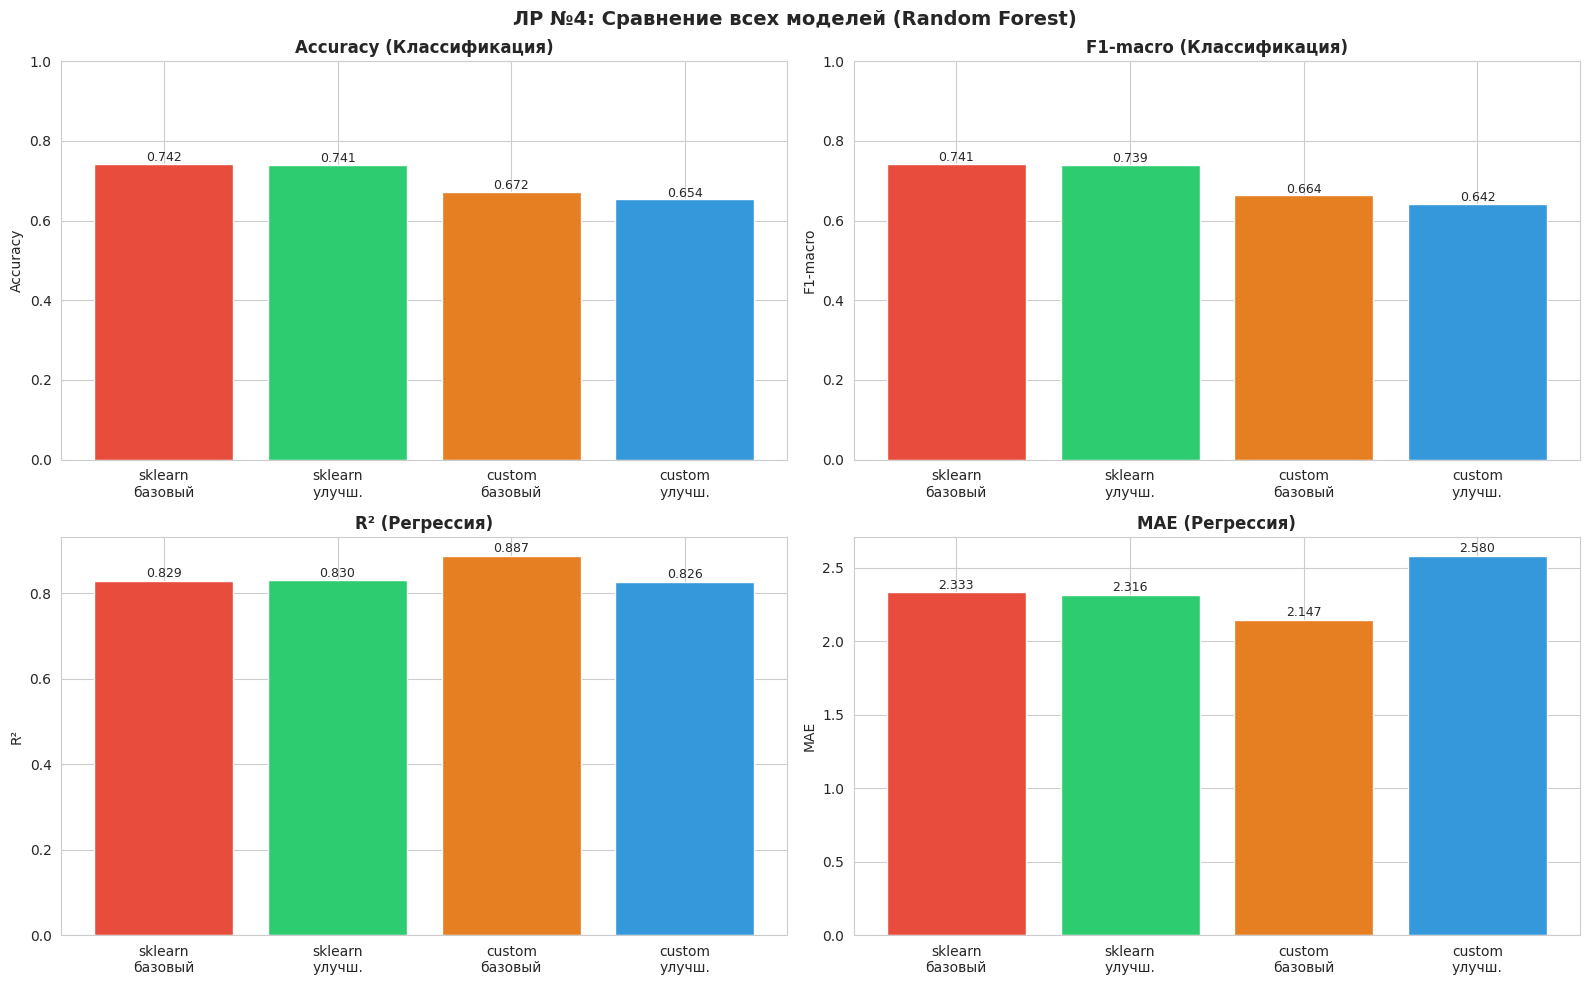

In [46]:
# Финальный дашборд: все 4 модели по всем метрикам

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
labels = ['sklearn\nбазовый', 'sklearn\nулучш.', 'custom\nбазовый', 'custom\nулучш.']
colors = ['#e74c3c', '#2ecc71', '#e67e22', '#3498db']

def dash_bar(ax, vals, title, ylabel, ylim=None):
    bars = ax.bar(labels, vals, color=colors)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() * 1.01,
                f'{b.get_height():.3f}', ha='center', fontsize=9)

dash_bar(axes[0,0], [acc_rf_base, acc_rf_improved, acc_my_base, acc_my_impr],
         'Accuracy (Классификация)', 'Accuracy', ylim=(0, 1))
dash_bar(axes[0,1], [f1_rf_base,  f1_rf_improved,  f1_my_base,  f1_my_impr],
         'F1-macro (Классификация)', 'F1-macro',  ylim=(0, 1))
dash_bar(axes[1,0], [r2_rf_base,  r2_rf_improved,  r2_my_base,  r2_my_impr],
         'R² (Регрессия)',            'R²')
dash_bar(axes[1,1], [mae_rf_base, mae_rf_improved, mae_my_base, mae_my_impr],
         'MAE (Регрессия)',           'MAE')

plt.suptitle('ЛР №4: Сравнение всех моделей (Random Forest)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Итоговые выводы

### 4e. Собственная базовая реализация vs sklearn (п.2)
- Собственная реализация Random Forest корректно воспроизводит ключевые механизмы: бутстрэп-выборки, случайное подмножество признаков и агрегацию предсказаний.
- Качество имплементированной модели отстает от sklearn, но не сильно.
- OOB-оценки собственной реализации и sklearn близки, что подтверждает правильность реализации механизма out-of-bag.
- Распределение важности признаков совпадает между реализациями, хотя точные значения различаются из-за случайного порядка деревьев.
- В отличие от одиночного дерева (ЛР №3), базовый Random Forest уже без настройки показывает значительно меньший разрыв train/test.

### 4j. Улучшенная собственная реализация vs улучшенный sklearn (п.3)
- Применение оптимальных гиперпараметров (`max_features`, `max_depth`, `min_samples_leaf`) из RandomizedSearchCV не улучшило результаты собственного леса аналогично sklearn.
- **Ключевое преимущество Random Forest перед одиночным деревом:** ансамблирование устраняет переобучение без явного задания `max_depth` — благодаря усреднению коррелированных деревьев снижается дисперсия.
- **`max_features < p`** — критически важный параметр: именно случайный выбор признаков де-коррелирует деревья и обеспечивает эффект ансамбля.
- OOB-оценка является надёжным заменителем кросс-валидации и хорошо отражает обобщающую способность модели.